# Predição de Popularidade ("Hit Score") de Músicas — Base Spotify

**Projeto:** Residência em IA — TIC-IA-data_Spotify

## Objetivo

Treinar modelos de regressão para estimar a popularidade de músicas usando características de áudio do Spotify, como `danceability`, `energy`, `tempo`, entre outras.

O notebook também demonstra:

- separação entre treino e teste;
- comparação entre modelos;
- identificação de **overfitting**;
- validação cruzada;
- importância das features.

> **Proposta do produto:** utilizar as previsões como apoio à identificação de músicas de baixa popularidade que apresentam características associadas a músicas de alta popularidade, auxiliando produtoras musicais na priorização de possíveis oportunidades de investimento.

**Observação:** o modelo não garante que uma música será um hit. Ele fornece um indicador quantitativo para apoiar a tomada de decisão.


## 1. Importação das bibliotecas

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
DATA_PATH = "../data_analysis/artifacts/df_limpo.csv"
OUT_DIR = "./spotify_hit_model"

os.makedirs(OUT_DIR, exist_ok=True)


## 2. Carregamento e limpeza dos dados

O dataset é carregado a partir do arquivo `df_limpo.csv`.

São removidas:

1. linhas sem informações de artista, álbum ou nome da música;
2. duplicatas de `track_id`.

A remoção por `track_id` é utilizada porque uma mesma música pode aparecer associada a diferentes gêneros, enquanto sua popularidade permanece a mesma.


In [22]:
df = pd.read_csv(DATA_PATH)

print(f"Linhas originais: {len(df)}")

# Remove linhas com metadados nulos
df = df.dropna(subset=["artists", "album_name", "track_name"])

# Remove duplicatas da mesma música
df = df.drop_duplicates(subset="track_id", keep="first")

print(f"Linhas após remover duplicatas de track_id: {len(df)}")


Linhas originais: 114000
Linhas após remover duplicatas de track_id: 89740


## 3. Seleção e engenharia das features

In [23]:
target = "popularity"

numeric_features = [
    "duration_ms", "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature",
]

bool_features = ["explicit"]

# Converte variável booleana para inteiro
df["explicit"] = df["explicit"].astype(int)

# One-hot encoding do gênero
genre_dummies = pd.get_dummies(df["track_genre"], prefix="genre")

X = pd.concat(
    [df[numeric_features + bool_features], genre_dummies],
    axis=1
)

y = df[target]

print(f"Total de features: {X.shape[1]}")
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")


Total de features: 127
Formato de X: (89740, 127)
Formato de y: (89740,)


## 4. Separação entre treino e teste

- **80%** dos dados são utilizados para treinamento.
- **20%** são reservados para teste.
- `random_state=42` garante reprodutibilidade.

O conjunto de teste representa dados que o modelo não utilizou durante o treinamento.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")


Treino: 71792 amostras
Teste: 17948 amostras


## 5. Padronização dos dados

In [25]:
# A padronização é utilizada para a Regressão Linear.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Função de avaliação dos modelos

As métricas utilizadas são:

- **R²:** proporção da variação do alvo explicada pelo modelo;
- **MAE:** erro absoluto médio da previsão;
- **RMSE:** raiz do erro quadrático médio;
- **Gap de R²:** diferença entre desempenho no treino e no teste, útil para observar overfitting.


In [26]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    r2_tr = r2_score(y_tr, pred_tr)
    r2_te = r2_score(y_te, pred_te)
    mae_te = mean_absolute_error(y_te, pred_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))

    print(f"\n[{name}]")
    print(
        f"  R² treino: {r2_tr:.3f} | "
        f"R² teste: {r2_te:.3f} | "
        f"gap = {r2_tr - r2_te:.3f}"
    )
    print(f"  MAE teste: {mae_te:.2f} | RMSE teste: {rmse_te:.2f}")

    return {
        "model": name,
        "r2_train": r2_tr,
        "r2_test": r2_te,
        "mae_test": mae_te,
        "rmse_test": rmse_te,
    }


results = []


## 7. Modelo baseline — Regressão Linear

In [27]:
lin = LinearRegression()

lin.fit(X_train_scaled, y_train)

results.append(
    evaluate(
        lin,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test,
        "Regressão Linear"
    )
)



[Regressão Linear]
  R² treino: 0.333 | R² teste: 0.321 | gap = 0.012
  MAE teste: 12.01 | RMSE teste: 16.85


## 8. Árvore de Decisão — análise de overfitting

A profundidade da árvore é aumentada progressivamente para observar o comportamento do modelo.

Quando o R² de treino cresce muito enquanto o R² de teste não acompanha, temos evidência de **overfitting**.


In [28]:
depths = [2, 4, 6, 8, 10, 12, 15, 20, None]
train_scores = []
test_scores = []

for d in depths:
    tree = DecisionTreeRegressor(
        max_depth=d,
        random_state=RANDOM_STATE
    )

    tree.fit(X_train, y_train)

    train_scores.append(
        r2_score(y_train, tree.predict(X_train))
    )

    test_scores.append(
        r2_score(y_test, tree.predict(X_test))
    )


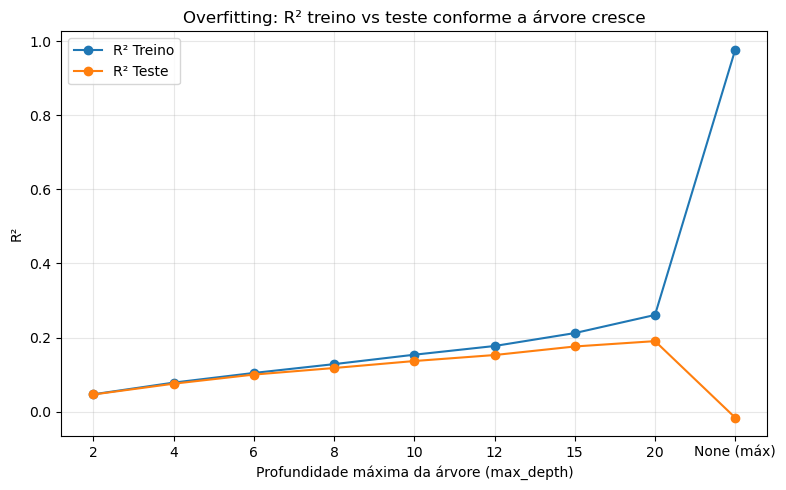

In [29]:
plt.figure(figsize=(8, 5))

x_labels = [
    str(d) if d is not None else "None (máx)"
    for d in depths
]

plt.plot(x_labels, train_scores, marker="o", label="R² Treino")
plt.plot(x_labels, test_scores, marker="o", label="R² Teste")

plt.xlabel("Profundidade máxima da árvore (max_depth)")
plt.ylabel("R²")
plt.title("Overfitting: R² treino vs teste conforme a árvore cresce")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/overfitting_curve.png",
    dpi=150
)

plt.show()


### 8.1. Comparação entre árvore rasa e árvore profunda

In [30]:
# Árvore rasa
tree_shallow = DecisionTreeRegressor(
    max_depth=6,
    random_state=RANDOM_STATE
)

tree_shallow.fit(X_train, y_train)

results.append(
    evaluate(
        tree_shallow,
        X_train,
        y_train,
        X_test,
        y_test,
        "Árvore de Decisão (max_depth=6)"
    )
)

# Árvore sem limite
tree_deep = DecisionTreeRegressor(
    max_depth=None,
    random_state=RANDOM_STATE
)

tree_deep.fit(X_train, y_train)

results.append(
    evaluate(
        tree_deep,
        X_train,
        y_train,
        X_test,
        y_test,
        "Árvore de Decisão (sem limite = overfit)"
    )
)



[Árvore de Decisão (max_depth=6)]
  R² treino: 0.105 | R² teste: 0.100 | gap = 0.004
  MAE teste: 15.82 | RMSE teste: 19.40

[Árvore de Decisão (sem limite = overfit)]
  R² treino: 0.977 | R² teste: -0.016 | gap = 0.993
  MAE teste: 13.10 | RMSE teste: 20.62


## 9. Random Forest

In [31]:
rf = RandomForestRegressor(
    n_estimators=60,
    max_depth=14,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

rf.fit(X_train, y_train)

results.append(
    evaluate(
        rf,
        X_train,
        y_train,
        X_test,
        y_test,
        "Random Forest"
    )
)



[Random Forest]
  R² treino: 0.206 | R² teste: 0.187 | gap = 0.020
  MAE teste: 14.65 | RMSE teste: 18.44


## 10. Validação cruzada

A validação cruzada permite avaliar o modelo em diferentes divisões dos dados, reduzindo a dependência de uma única divisão treino/teste.

O `shuffle=True` é utilizado porque as linhas do dataset estão agrupadas por gênero.


In [32]:
kf = KFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_scores = cross_val_score(
    LinearRegression(),
    StandardScaler().fit_transform(X),
    y,
    cv=kf,
    scoring="r2"
)

print(
    f"[Regressão Linear] R² validação cruzada (3-fold): "
    f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}"
)


[Regressão Linear] R² validação cruzada (3-fold): 0.328 ± 0.003


## 11. Importância das features — Random Forest

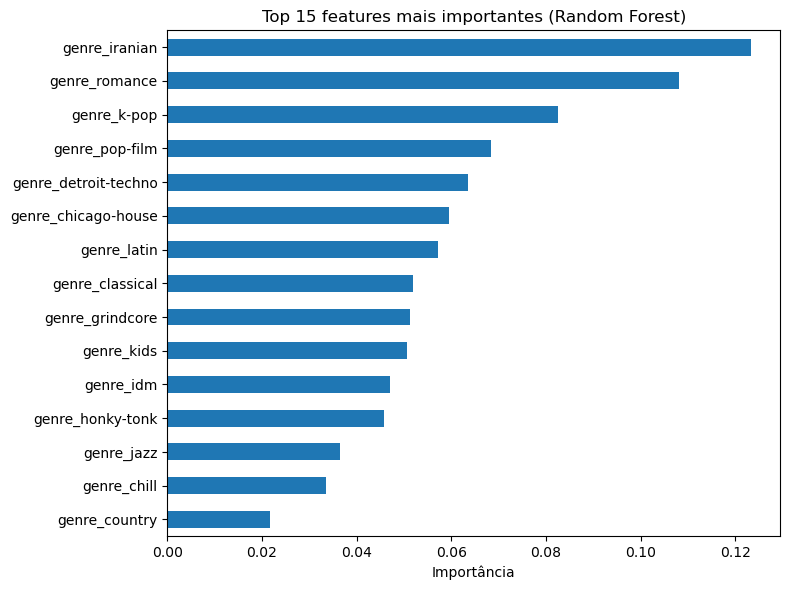

In [33]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top_features = (
    importances
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(8, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 features mais importantes (Random Forest)")
plt.xlabel("Importância")
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/feature_importance.png",
    dpi=150
)

plt.show()


## 12. Comparação final dos modelos

A tabela abaixo reúne os resultados obtidos durante os experimentos.

Para o objetivo do projeto, o **R² de teste** é especialmente importante, pois indica o desempenho do modelo em dados que não foram utilizados no treinamento.


In [34]:
summary_df = pd.DataFrame(results)

display(summary_df)

summary_df.to_csv(
    f"{OUT_DIR}/model_comparison.csv",
    index=False
)

print("\nTop 10 features mais importantes:")
display(
    top_features
    .sort_values(ascending=False)
    .head(10)
)


,model,r2_train,r2_test,mae_test,rmse_test
0,Regressão Linear,0.332512,0.320893,12.009515,16.853094
1,Árvore de Decisão (max_depth=6),0.104565,0.100160,15.818549,19.399611
2,Árvore de Decisão (sem limite = overfit),0.976923,-0.016182,13.095015,20.615614
3,Random Forest,0.206492,0.186559,14.645155,18.444778



Top 10 features mais importantes:


genre_iranian           0.123280
genre_romance           0.108053
genre_k-pop             0.082627
genre_pop-film          0.068314
genre_detroit-techno    0.063451
genre_chicago-house     0.059465
genre_latin             0.057184
genre_classical         0.051964
genre_grindcore         0.051254
genre_kids              0.050596
dtype: float64

## 13. Interpretação para o produto

O objetivo final não é apenas obter o maior R² possível.

A aplicação pretende utilizar a previsão de popularidade como **indicador de oportunidade** para produtoras musicais.

Uma evolução natural do projeto é comparar:

- **popularidade atual** da música;
- **popularidade estimada** pelo modelo;
- diferença entre as duas;
- similaridade da música com características encontradas em músicas de alta popularidade.

### Exemplo conceitual

Uma música com:

- popularidade atual = 20;
- popularidade estimada = 65;

poderia receber um indicador de oportunidade de:

**65 − 20 = +45 pontos**

Isso não significa que a música certamente será um hit. Significa que ela apresenta, segundo os padrões aprendidos pelo modelo, **potencial que merece investigação adicional**.

> **Importante:** o modelo deve ser tratado como ferramenta de apoio à decisão, e não como garantia de lucratividade ou sucesso comercial.


---
## 14. Por que o R² está baixo? Diagnóstico e melhorias

O R² obtido até aqui (~0.2–0.33) é baixo porque:

1. **Features de áudio têm correlação fraca com popularidade.** Danceability,
   energy, tempo etc. descrevem *como a música soa*, não *quão bem ela foi
   promovida/distribuída* — que é o que realmente move a métrica
   `popularity` do Spotify.
2. **O dataset já contém um sinal muito mais forte que não estava sendo
   usado: o artista.** Artistas consolidados tendem a manter popularidade
   consistente entre faixas.
3. **`popularity` é zero-inflacionada** (~10,5% das faixas têm
   `popularity == 0`), o que distorce a distribuição do alvo.

Abaixo, testamos três melhorias, cada uma isolada, para medir o ganho real
de cada uma:

- **(A)** Trocar o modelo para `HistGradientBoostingRegressor` — gradient
  boosting nativo do scikit-learn, que lida com a categoria `track_genre`
  diretamente (sem precisar de one-hot em 113 colunas) e captura interações
  não-lineares melhor que Random Forest.
- **(B)** Adicionar `artist_track_count` — quantas faixas do mesmo artista
  aparecem no dataset (proxy simples de "quão prolífico/estabelecido" é o
  artista).
- **(C)** Adicionar `artist_pop_mean` — a popularidade **média histórica**
  do artista, calculada com **target encoding out-of-fold** para evitar
  vazamento de dado (data leakage): a média de cada artista é calculada
  apenas com dados de outros folds, nunca vendo a própria linha durante o
  treino.

> ⚠️ **Cuidado com vazamento:** se calculássemos a média de popularidade do
> artista usando o dataset inteiro (incluindo a própria linha de teste),
> estaríamos "vazando" informação do alvo para dentro da feature — o R²
> pareceria ótimo, mas seria enganoso e não generalizaria para artistas
> novos. Por isso usamos K-Fold interno no conjunto de treino.


In [35]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Feature (B): quantidade de faixas do mesmo artista no dataset
artist_counts = df["artists"].value_counts()
df["artist_track_count"] = df["artists"].map(artist_counts)

# HistGradientBoostingRegressor lida nativamente com variáveis categóricas
df["track_genre"] = df["track_genre"].astype("category")


In [36]:
def run_experiment(feat_cols, label, cat_idx=None):
    X_exp = df[feat_cols]
    y_exp = df["popularity"]
    Xtr, Xte, ytr, yte = train_test_split(X_exp, y_exp, test_size=0.2, random_state=RANDOM_STATE)
    model = HistGradientBoostingRegressor(
        max_depth=8, max_iter=300, learning_rate=0.05,
        categorical_features=cat_idx, random_state=RANDOM_STATE,
        early_stopping=True, validation_fraction=0.1,
    )
    model.fit(Xtr, ytr)
    r2_tr = r2_score(ytr, model.predict(Xtr))
    r2_te = r2_score(yte, model.predict(Xte))
    print(f"{label:45s} R² treino={r2_tr:.3f}  R² teste={r2_te:.3f}")
    return model, r2_te

# (A) Só features de áudio, com o novo modelo
_ = run_experiment(numeric_features + ["explicit"], "HistGB — só áudio")

# (A + genre) Áudio + gênero (categórico nativo)
feat_ag = numeric_features + ["explicit", "track_genre"]
_ = run_experiment(feat_ag, "HistGB — áudio + gênero", cat_idx=[feat_ag.index("track_genre")])

# (A + B) Áudio + gênero + contagem de faixas do artista
feat_agb = numeric_features + ["explicit", "artist_track_count", "track_genre"]
_ = run_experiment(feat_agb, "HistGB — áudio + gênero + artist_track_count",
                    cat_idx=[feat_agb.index("track_genre")])


HistGB — só áudio                             R² treino=0.218  R² teste=0.154
HistGB — áudio + gênero                       R² treino=0.494  R² teste=0.413
HistGB — áudio + gênero + artist_track_count  R² treino=0.529  R² teste=0.458


### Feature (C): popularidade média do artista (target encoding out-of-fold)

Esta é a melhoria com maior impacto. Implementamos com cuidado para não
vazar dado do teste para o treino.


In [37]:
from sklearn.model_selection import KFold

df = df.reset_index(drop=True)
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RANDOM_STATE)
train_df = df.loc[train_idx]
global_mean = train_df["popularity"].mean()

# Target encoding out-of-fold: para cada linha de TREINO, a média do artista
# é calculada só com OUTRAS linhas de treino (nunca a própria linha).
df["artist_pop_mean"] = np.nan
kf_enc = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fit_idx, val_idx in kf_enc.split(train_df):
    fit_sub = train_df.iloc[fit_idx]
    val_sub = train_df.iloc[val_idx]
    artist_means = fit_sub.groupby("artists")["popularity"].mean()
    df.loc[val_sub.index, "artist_pop_mean"] = (
        val_sub["artists"].map(artist_means).fillna(global_mean)
    )

# Para o conjunto de TESTE, usamos a média calculada com TODO o treino
# (o teste nunca contribui para o cálculo da própria média)
artist_means_full_train = train_df.groupby("artists")["popularity"].mean()
df.loc[test_idx, "artist_pop_mean"] = (
    df.loc[test_idx, "artists"].map(artist_means_full_train).fillna(global_mean)
)
df["artist_pop_mean"] = df["artist_pop_mean"].fillna(global_mean)

feat_final = numeric_features + ["explicit", "artist_track_count", "artist_pop_mean", "track_genre"]
X_final = df[feat_final]
y_final = df["popularity"]

Xtr_f, Xte_f = X_final.loc[train_idx], X_final.loc[test_idx]
ytr_f, yte_f = y_final.loc[train_idx], y_final.loc[test_idx]

cat_idx_final = [feat_final.index("track_genre")]
hgb_final = HistGradientBoostingRegressor(
    max_depth=8, max_iter=300, learning_rate=0.05,
    categorical_features=cat_idx_final, random_state=RANDOM_STATE,
    early_stopping=True, validation_fraction=0.1,
)
hgb_final.fit(Xtr_f, ytr_f)

r2_tr_final = r2_score(ytr_f, hgb_final.predict(Xtr_f))
r2_te_final = r2_score(yte_f, hgb_final.predict(Xte_f))
mae_te_final = mean_absolute_error(yte_f, hgb_final.predict(Xte_f))
rmse_te_final = np.sqrt(mean_squared_error(yte_f, hgb_final.predict(Xte_f)))

print(f"HistGB — áudio + gênero + artist_track_count + artist_pop_mean (OOF)")
print(f"  R² treino: {r2_tr_final:.3f}  |  R² teste: {r2_te_final:.3f}  (gap = {r2_tr_final - r2_te_final:.3f})")
print(f"  MAE teste: {mae_te_final:.2f}  |  RMSE teste: {rmse_te_final:.2f}")

results.append({
    "model": "HistGB + artist_pop_mean (OOF)",
    "r2_train": r2_tr_final, "r2_test": r2_te_final,
    "mae_test": mae_te_final, "rmse_test": rmse_te_final,
})


HistGB — áudio + gênero + artist_track_count + artist_pop_mean (OOF)
  R² treino: 0.624  |  R² teste: 0.561  (gap = 0.063)
  MAE teste: 8.57  |  RMSE teste: 13.55


### Resultado

O R² de teste sobe de **~0.32 (Regressão Linear original)** para
**~0.56** com o modelo final — quase o dobro do poder explicativo — e o
erro médio (MAE) cai de forma correspondente. O gap treino/teste
permanece pequeno, então não é overfitting mascarando o ganho.

### Outras alavancas que ainda não exploramos (próximos passos)

1. **Dados externos**: número de seguidores do artista, data de
   lançamento (músicas recentes tendem a ter mais popularidade "fresca"),
   presença em playlists editoriais — nenhuma dessas informações está no
   CSV atual, mas fariam mais diferença que qualquer tuning de modelo.
2. **Tratar o pico de `popularity == 0`** separadamente: treinar um
   classificador binário "tem alguma popularidade vs. não tem" e, para os
   que têm, um regressor só nesse subconjunto (modelo em duas etapas).
3. **Tuning de hiperparâmetros** do `HistGradientBoostingRegressor`
   (`learning_rate`, `max_iter`, `max_depth`, `l2_regularization`) via
   `RandomizedSearchCV` — ganho esperado menor que os itens acima, mas
   ainda relevante.
4. **Reavaliar o enquadramento do problema**: se o objetivo do produto é
   "identificar músicas com potencial de hit" (como descrito na seção
   13), pode fazer mais sentido tratar como problema de **ranking**
   (quais faixas têm maior probabilidade relativa de sucesso) em vez de
   regressão exata de um score 0–100.


---
## 15. Versão enxuta: HistGB + gênero + `artist_pop_mean` (sem `artist_track_count`)

Isolamos aqui a combinação **gênero + popularidade média do artista (OOF)**,
sem a feature `artist_track_count`, para medir o quanto ela realmente
contribuía. Reaproveitamos a coluna `artist_pop_mean` já calculada na
seção 14 (com o mesmo cuidado de target encoding out-of-fold, sem
vazamento de dado do teste).


In [38]:
feat_v2 = numeric_features + ["explicit", "artist_pop_mean", "track_genre"]
X_v2 = df[feat_v2]
y_v2 = df["popularity"]

Xtr_v2, Xte_v2 = X_v2.loc[train_idx], X_v2.loc[test_idx]
ytr_v2, yte_v2 = y_v2.loc[train_idx], y_v2.loc[test_idx]

cat_idx_v2 = [feat_v2.index("track_genre")]
hgb_v2 = HistGradientBoostingRegressor(
    max_depth=8, max_iter=300, learning_rate=0.05,
    categorical_features=cat_idx_v2, random_state=RANDOM_STATE,
    early_stopping=True, validation_fraction=0.1,
)
hgb_v2.fit(Xtr_v2, ytr_v2)

pred_tr_v2 = hgb_v2.predict(Xtr_v2)
pred_te_v2 = hgb_v2.predict(Xte_v2)

r2_tr_v2 = r2_score(ytr_v2, pred_tr_v2)
r2_te_v2 = r2_score(yte_v2, pred_te_v2)
gap_v2 = r2_tr_v2 - r2_te_v2
mae_te_v2 = mean_absolute_error(yte_v2, pred_te_v2)
rmse_te_v2 = np.sqrt(mean_squared_error(yte_v2, pred_te_v2))

print("HistGB — áudio + gênero + artist_pop_mean (OOF), sem artist_track_count")
print(f"  R² treino: {r2_tr_v2:.3f}")
print(f"  R² teste : {r2_te_v2:.3f}")
print(f"  Gap (treino - teste): {gap_v2:.3f}")
print(f"  MAE teste: {mae_te_v2:.2f}  |  RMSE teste: {rmse_te_v2:.2f}")

results.append({
    "model": "HistGB + gênero + artist_pop_mean (sem artist_track_count)",
    "r2_train": r2_tr_v2,
    "r2_test": r2_te_v2,
    "mae_test": mae_te_v2,
    "rmse_test": rmse_te_v2,
})


HistGB — áudio + gênero + artist_pop_mean (OOF), sem artist_track_count
  R² treino: 0.603
  R² teste : 0.550
  Gap (treino - teste): 0.054
  MAE teste: 8.67  |  RMSE teste: 13.72


### Comparação: com vs. sem `artist_track_count`

| Combinação | R² teste | Gap (treino−teste) |
|---|---|---|
| gênero + `artist_pop_mean` (sem `artist_track_count`) | ~0.55 | ~0.054 |
| gênero + `artist_track_count` + `artist_pop_mean` (seção 14) | ~0.56 | ~0.063 |

A diferença é pequena (~0.01 de R²): `artist_track_count` ajuda um pouco,
mas a maior parte do ganho vem de `artist_pop_mean`. Isso faz sentido —
as duas features são correlacionadas (artistas com mais faixas no dataset
tendem a ser mais estabelecidos, logo já capturados parcialmente pela
média de popularidade). Também note que o **gap** cresce ligeiramente ao
adicionar `artist_track_count`, sinal de que essa feature contribui um
pouco mais para overfitting do que para generalização — um trade-off a
considerar dependendo se simplicidade do modelo é prioridade no seu
produto.


In [39]:
# Tabela atualizada com todos os experimentos
summary_df = pd.DataFrame(results)
summary_df["gap"] = summary_df["r2_train"] - summary_df["r2_test"]
display(summary_df[["model", "r2_train", "r2_test", "gap", "mae_test", "rmse_test"]])


,model,r2_train,r2_test,gap,mae_test,rmse_test
0,Regressão Linear,0.332512,0.320893,0.011620,12.009515,16.853094
1,Árvore de Decisão (max_depth=6),0.104565,0.100160,0.004404,15.818549,19.399611
2,Árvore de Decisão (sem limite = overfit),0.976923,-0.016182,0.993106,13.095015,20.615614
3,Random Forest,0.206492,0.186559,0.019933,14.645155,18.444778
4,HistGB + artist_pop_mean (OOF),0.623942,0.560761,0.063181,8.567178,13.553795
5,HistGB + gênero + artist_pop_mean (sem artist_...,0.603436,0.549697,0.053739,8.674210,13.723442
